# PKCERT Task 22 -- Part D & Part E (GPU portion)
### Feedforward Neural Networks on MNIST/Fashion-MNIST, Regularization & GPU-Accelerated Training

Run this notebook top-to-bottom on a **GPU runtime**
(Colab: `Runtime > Change runtime type > T4 GPU`. Kaggle: `Settings > Accelerator > GPU`).

Everything below runs from a clean install and produces real, measured
numbers on whatever GPU the runtime assigns -- nothing here is
pre-filled or estimated. Expected total runtime on a free-tier T4:
roughly 3-6 minutes.

This notebook is self-contained (does not depend on any other file) so it
can be uploaded and run standalone. It reimplements the small NumPy MLP
used elsewhere in Task 22 so the NumPy-vs-framework comparison in Part E
works without external imports.

In [1]:
!pip install -q torch torchvision --upgrade
import torch, torchvision
print("PyTorch", torch.__version__, "| torchvision", torchvision.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/

## Part D: GPU Basics & Acceleration

### D1-D2: device check

In [2]:
import torch

cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)
if cuda_available:
    print("Device name:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"Total memory: {props.total_memory / 1e9:.2f} GB")
    print(f"Multiprocessors: {props.multi_processor_count}")
    print("CUDA capability:", torch.cuda.get_device_capability(0))
else:
    raise RuntimeError(
        "No GPU detected. In Colab: Runtime > Change runtime type > select a GPU "
        "(T4 is free-tier). In Kaggle: Settings > Accelerator > GPU. This notebook "
        "is meant to be run on GPU -- that is the entire point of Part D/E."
    )

device = torch.device("cuda")

CUDA available: True
Device name: Tesla T4
Total memory: 15.64 GB
Multiprocessors: 40
CUDA capability: (7, 5)


### D3: CPU vs GPU wall-clock benchmark

A matrix-multiplication-heavy workload representative of what a feedforward
network actually does per step: large batched matmuls. Timed identically on
CPU and GPU, with a GPU warm-up call excluded from the timed region (the
first CUDA call in a process pays a one-off context/kernel-compile cost that
has nothing to do with the hardware's steady-state throughput).

In [3]:
import time

def matmul_benchmark(device, size=4096, n_reps=20):
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_reps):
        c = a @ b
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_reps

# warm-up (excluded from timing): first CUDA call compiles/caches kernels
_ = matmul_benchmark(device, size=512, n_reps=3)

cpu_time = matmul_benchmark(torch.device("cpu"), size=4096, n_reps=20)
gpu_time = matmul_benchmark(device, size=4096, n_reps=20)
speedup = cpu_time / gpu_time

print(f"4096x4096 matmul, mean of 20 reps:")
print(f"  CPU: {cpu_time*1000:.2f} ms/rep")
print(f"  GPU: {gpu_time*1000:.2f} ms/rep")
print(f"  Speedup: {speedup:.1f}x")

4096x4096 matmul, mean of 20 reps:
  CPU: 1696.96 ms/rep
  GPU: 35.26 ms/rep
  Speedup: 48.1x


**Mechanistic explanation** (why this speedup happens, not just that it
does): a CPU core executes matrix multiplication largely serially across a
handful of cores (with some SIMD vectorization), so a 4096x4096 matmul's
~137 billion multiply-add operations queue through a small number of
execution units. A GPU is built from thousands of much simpler cores
(a T4 has 2,560 CUDA cores) organized in Streaming Multiprocessors that
execute the *same* instruction across many data elements simultaneously
(SIMT). Matrix multiplication decomposes almost perfectly into that
pattern -- each output element is an independent dot product -- so the
GPU can compute thousands of output elements in parallel instead of
one-at-a-time. The bottleneck shifts from raw compute to memory bandwidth
(how fast operands can be streamed to the cores), which is exactly why GPUs
are additionally built with far higher memory bandwidth than CPUs (a T4:
~320 GB/s, vs a typical CPU: 20-50 GB/s).

### D4: mixed-precision training

Mixed precision runs most operations in fp16/bf16 (half the bits of fp32)
while keeping a small set of precision-sensitive operations (e.g. loss
accumulation) in fp32, via `torch.autocast` + `GradScaler`. This roughly
halves memory bandwidth demand and lets Tensor-Core-equipped GPUs (T4 and
newer) use a dedicated fast path for fp16 matmuls -- the actual mechanism
behind the speedup, not just "smaller numbers are faster" as a slogan.

In [4]:
import torch.nn as nn

def build_bench_net():
    return nn.Sequential(
        nn.Linear(2048, 2048), nn.ReLU(),
        nn.Linear(2048, 2048), nn.ReLU(),
        nn.Linear(2048, 1024), nn.ReLU(),
        nn.Linear(1024, 10),
    ).to(device)

def train_step_benchmark(use_amp, n_steps=30, batch_size=512):
    net = build_bench_net()
    opt = torch.optim.SGD(net.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    x = torch.randn(batch_size, 2048, device=device)
    y = torch.randint(0, 10, (batch_size,), device=device)

    # warm-up
    for _ in range(3):
        opt.zero_grad()
        with torch.autocast(device_type="cuda", enabled=use_amp):
            loss = criterion(net(x), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

    t0 = time.perf_counter()
    for _ in range(n_steps):
        opt.zero_grad()
        with torch.autocast(device_type="cuda", enabled=use_amp):
            loss = criterion(net(x), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / n_steps
    peak_mem = torch.cuda.max_memory_allocated() / 1e6
    return elapsed, peak_mem

fp32_time, fp32_mem = train_step_benchmark(use_amp=False)
amp_time, amp_mem = train_step_benchmark(use_amp=True)

print(f"FP32:          {fp32_time*1000:.2f} ms/step, peak memory {fp32_mem:.1f} MB")
print(f"Mixed (AMP):   {amp_time*1000:.2f} ms/step, peak memory {amp_mem:.1f} MB")
print(f"Speedup: {fp32_time/amp_time:.2f}x | Memory reduction: {(1 - amp_mem/fp32_mem)*100:.1f}%")

/tmp/ipykernel_762/426370892.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


FP32:          7.26 ms/step, peak memory 109.4 MB
Mixed (AMP):   3.05 ms/step, peak memory 113.6 MB
Speedup: 2.38x | Memory reduction: -3.8%


### D5: free-tier GPU constraints and mitigations

Two real constraints on Colab/Kaggle free tiers, and how this notebook (or
a longer one) should handle each:

1. **Session/idle timeouts.** Colab free tier disconnects idle sessions
   (~90 min idle, ~12 hr hard cap) and Kaggle enforces a weekly GPU-hour
   quota (30 hrs/week) plus a 12-hour hard session cap. Mitigation: keep
   any individual run well under an hour, and for anything longer,
   checkpoint model weights + optimizer state to disk (`torch.save`) every
   N steps/epochs so a disconnected session can resume from the last
   checkpoint instead of restarting from scratch.
2. **Usage quota / GPU availability.** Free-tier GPU access is not
   guaranteed on demand -- heavy usage can mean waiting for an available
   GPU or being bumped to CPU. Mitigation: keep the compute budget for any
   one run explicit and small (this notebook self-imposes a 10-minute
   budget in Part E below), so a run comfortably finishes within a single
   granted session even under contention, and design the training loop to
   be resumable (checkpointing, as above) rather than assuming one
   uninterrupted block of GPU time.

## Part E: Real-World Application & Integration (GPU portion)

This section trains a PyTorch feedforward network with the full
regularization stack (Dropout + BatchNorm + Early Stopping) on GPU, then
compares it against a from-scratch NumPy MLP (reimplemented below,
identical architecture/math to the one gradient-checked and used
elsewhere in Task 22) via a statistical prediction-agreement analysis, and
finally stress-tests both models on a corrupted test set.

**Compute budget** (justified, per D5): self-imposed at **10 minutes of
GPU time total** for this section -- generous for a network this size on a
T4, while keeping the notebook fast enough to comfortably fit inside a
single free-tier session even under contention. Budget split: ~40% model
architecture size (kept modest: two hidden layers, 256/128 units, so
training is fast and the 10-minute budget goes toward more epochs rather
than a wider network), ~30% regularization strength (dropout p=0.3,
moderate, chosen to regularize without slowing convergence enough to
threaten the time budget), ~30% training epochs (up to 30, with early
stopping typically ending it sooner).

In [5]:
!pip install -q torchvision
import numpy as np
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader, random_split

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

raw_train_full = FashionMNIST(root="./data", train=True, download=True)
raw_test = FashionMNIST(root="./data", train=False, download=True)

N_TRAIN, N_VAL = 50000, 10000
generator = torch.Generator().manual_seed(RANDOM_STATE)
train_subset, val_subset = random_split(raw_train_full, [N_TRAIN, N_VAL], generator=generator)

train_images_raw = raw_train_full.data[train_subset.indices].float() / 255.0
mean, std = train_images_raw.mean().item(), train_images_raw.std().item()
print(f"Normalization stats (train split only): mean={mean:.4f}, std={std:.4f}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),
    transforms.Lambda(lambda x: x.view(-1)),
])
train_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
val_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
test_dataset = FashionMNIST(root="./data", train=False, download=False, transform=transform)

def loader_to_numpy(ds):
    dl = DataLoader(ds, batch_size=len(ds), shuffle=False)
    X, y = next(iter(dl))
    return X.numpy().astype(np.float64), y.numpy()

X_train_np, y_train_np = loader_to_numpy(train_subset)
X_val_np, y_val_np = loader_to_numpy(val_subset)
X_test_np, y_test_np = loader_to_numpy(test_dataset)
print("Shapes:", X_train_np.shape, X_val_np.shape, X_test_np.shape)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]


Normalization stats (train split only): mean=0.2857, std=0.3529
Shapes: (50000, 784) (10000, 784) (10000, 784)


### E-GPU-1: PyTorch model, full regularization stack, trained on GPU

In [6]:
import torch.nn as nn

class RegularizedNet(nn.Module):
    def __init__(self, n_in=784, h1=256, h2=128, n_out=10, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1); self.bn1 = nn.BatchNorm1d(h1)
        self.fc2 = nn.Linear(h1, h2);   self.bn2 = nn.BatchNorm1d(h2)
        self.fc3 = nn.Linear(h2, n_out)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(p)

    def forward(self, x):
        x = self.drop(self.relu(self.bn1(self.fc1(x))))
        x = self.drop(self.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

X_train_t = torch.tensor(X_train_np, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_np, dtype=torch.long, device=device)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val_np, dtype=torch.long, device=device)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_np, dtype=torch.long, device=device)

torch.manual_seed(RANDOM_STATE)
net = RegularizedNet().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

BATCH_SIZE = 256
MAX_EPOCHS = 30
PATIENCE = 5

best_val_loss, patience_ctr, best_state = float("inf"), 0, None
train_losses, val_losses, train_accs, val_accs = [], [], [], []

gpu_train_t0 = time.perf_counter()
for epoch in range(MAX_EPOCHS):
    net.train()
    perm = torch.randperm(X_train_t.shape[0], device=device)
    for start in range(0, X_train_t.shape[0], BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        loss = criterion(net(X_train_t[idx]), y_train_t[idx])
        loss.backward()
        optimizer.step()

    net.eval()
    with torch.no_grad():
        tr_logits, va_logits = net(X_train_t), net(X_val_t)
        tr_loss, va_loss = criterion(tr_logits, y_train_t).item(), criterion(va_logits, y_val_t).item()
        tr_acc = (tr_logits.argmax(1) == y_train_t).float().mean().item()
        va_acc = (va_logits.argmax(1) == y_val_t).float().mean().item()
    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    print(f"epoch {epoch+1:2d}/{MAX_EPOCHS}  train loss {tr_loss:.4f}  val loss {va_loss:.4f}  "
          f"train acc {tr_acc:.4f}  val acc {va_acc:.4f}")

    if va_loss < best_val_loss - 1e-4:
        best_val_loss, best_state, patience_ctr = va_loss, {k: v.clone() for k, v in net.state_dict().items()}, 0
    else:
        patience_ctr += 1
    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}, restoring epoch {epoch+1-PATIENCE} weights")
        net.load_state_dict(best_state)
        break

torch.cuda.synchronize()
gpu_train_time = time.perf_counter() - gpu_train_t0
print(f"\nGPU training time (this section's model): {gpu_train_time:.2f}s over {len(train_losses)} epochs")

net.eval()
with torch.no_grad():
    test_preds_torch = net(X_test_t).argmax(1).cpu().numpy()
torch_test_acc = (test_preds_torch == y_test_np).mean()
print(f"PyTorch (GPU) test accuracy: {torch_test_acc:.4f}")

epoch  1/30  train loss 0.3684  val loss 0.3948  train acc 0.8677  val acc 0.8580
epoch  2/30  train loss 0.3283  val loss 0.3621  train acc 0.8786  val acc 0.8691
epoch  3/30  train loss 0.3035  val loss 0.3427  train acc 0.8876  val acc 0.8743
epoch  4/30  train loss 0.2798  val loss 0.3354  train acc 0.8968  val acc 0.8756
epoch  5/30  train loss 0.2603  val loss 0.3202  train acc 0.9039  val acc 0.8835
epoch  6/30  train loss 0.2483  val loss 0.3128  train acc 0.9096  val acc 0.8877
epoch  7/30  train loss 0.2326  val loss 0.3071  train acc 0.9128  val acc 0.8892
epoch  8/30  train loss 0.2220  val loss 0.3007  train acc 0.9176  val acc 0.8884
epoch  9/30  train loss 0.2107  val loss 0.2971  train acc 0.9219  val acc 0.8926
epoch 10/30  train loss 0.2043  val loss 0.2953  train acc 0.9255  val acc 0.8946
epoch 11/30  train loss 0.1935  val loss 0.2891  train acc 0.9292  val acc 0.8961
epoch 12/30  train loss 0.1905  val loss 0.2920  train acc 0.9298  val acc 0.8925
epoch 13/30  tra

### E-GPU-2: from-scratch NumPy MLP, same architecture and regularization
math (Dropout + BatchNorm), reimplemented here so this notebook is
self-contained -- identical math to the version gradient-checked
elsewhere in Task 22 (see `numpy_network.py`).

In [7]:
def relu(z): return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(z.dtype)
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)
def cross_entropy_loss(probs, y_onehot, eps=1e-12):
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))
def one_hot(y, n_classes=10):
    Y = np.zeros((y.size, n_classes)); Y[np.arange(y.size), y] = 1.0
    return Y

class BatchNormLayer:
    def __init__(self, dim, momentum=0.9, eps=1e-5):
        self.gamma = np.ones(dim); self.beta = np.zeros(dim)
        self.running_mean = np.zeros(dim); self.running_var = np.ones(dim)
        self.momentum, self.eps = momentum, eps
    def forward(self, z, training=True):
        if training:
            mu, var = z.mean(0), z.var(0)
            self.running_mean = self.momentum*self.running_mean + (1-self.momentum)*mu
            self.running_var = self.momentum*self.running_var + (1-self.momentum)*var
        else:
            mu, var = self.running_mean, self.running_var
        self.std_inv = 1.0/np.sqrt(var+self.eps)
        self.z_norm = (z-mu)*self.std_inv
        self.z_centered = z-mu
        return self.gamma*self.z_norm + self.beta
    def backward(self, dout):
        N = dout.shape[0]
        dgamma = np.sum(dout*self.z_norm, axis=0)
        dbeta = np.sum(dout, axis=0)
        dz_norm = dout*self.gamma
        dvar = np.sum(dz_norm*self.z_centered*-0.5*self.std_inv**3, axis=0)
        dmu = np.sum(dz_norm*-self.std_inv, axis=0) + dvar*np.mean(-2*self.z_centered, axis=0)
        dz = dz_norm*self.std_inv + dvar*2*self.z_centered/N + dmu/N
        return dz, dgamma, dbeta

class DropoutLayer:
    def __init__(self, p=0.5): self.p = p
    def forward(self, a, training=True):
        if training:
            self.mask = (np.random.rand(*a.shape) > self.p) / (1-self.p)
            return a*self.mask
        return a
    def backward(self, da): return da*self.mask

class NumpyMLP:
    def __init__(self, sizes, dropout_p=0.3, seed=42):
        rng = np.random.default_rng(seed)
        self.sizes = sizes
        self.W = [rng.standard_normal((sizes[i], sizes[i+1]))*np.sqrt(2.0/sizes[i]) for i in range(len(sizes)-1)]
        self.b = [np.zeros(sizes[i+1]) for i in range(len(sizes)-1)]
        self.bn = [BatchNormLayer(sizes[i+1]) for i in range(len(sizes)-2)]
        self.do = [DropoutLayer(dropout_p) for i in range(len(sizes)-2)]

    def forward(self, X, training=True):
        self.cache_in = [X]; self.cache_z = []; self.cache_bn_out = []
        a = X
        for i in range(len(self.W)-1):
            z = a @ self.W[i] + self.b[i]
            bn_out = self.bn[i].forward(z, training)
            relu_out = relu(bn_out)
            a = self.do[i].forward(relu_out, training)
            self.cache_z.append(z); self.cache_bn_out.append(bn_out)
            self.cache_in.append(a)
        z_out = a @ self.W[-1] + self.b[-1]
        self.probs = softmax(z_out)
        return self.probs

    def backward(self, y_onehot):
        N = y_onehot.shape[0]
        grads = {"dW": [None]*len(self.W), "db": [None]*len(self.W)}
        dz = (self.probs - y_onehot)/N
        grads["dW"][-1] = self.cache_in[-1].T @ dz
        grads["db"][-1] = dz.sum(0)
        da = dz @ self.W[-1].T
        for i in reversed(range(len(self.W)-1)):
            da = self.do[i].backward(da)
            dbn_out = da*relu_deriv(self.cache_bn_out[i])
            dz_pre, dgamma, dbeta = self.bn[i].backward(dbn_out)
            self.bn[i].dgamma, self.bn[i].dbeta = dgamma, dbeta
            grads["dW"][i] = self.cache_in[i].T @ dz_pre
            grads["db"][i] = dz_pre.sum(0)
            if i > 0: da = dz_pre @ self.W[i].T
        return grads

    def step(self, grads, lr):
        for i in range(len(self.W)):
            self.W[i] -= lr*grads["dW"][i]; self.b[i] -= lr*grads["db"][i]
        for bn in self.bn:
            bn.gamma -= lr*bn.dgamma; bn.beta -= lr*bn.dbeta

    def predict(self, X): return self.forward(X, training=False).argmax(1)

np_model = NumpyMLP([784, 256, 128, 10], dropout_p=0.3, seed=RANDOM_STATE)
Y_train_np = one_hot(y_train_np)
NP_EPOCHS = 20
np_t0 = time.perf_counter()
for epoch in range(NP_EPOCHS):
    perm = np.random.RandomState(RANDOM_STATE+epoch).permutation(X_train_np.shape[0])
    for start in range(0, X_train_np.shape[0], BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        np_model.forward(X_train_np[idx], training=True)
        grads = np_model.backward(Y_train_np[idx])
        np_model.step(grads, lr=0.1)
    if (epoch+1) % 5 == 0:
        val_acc = (np_model.predict(X_val_np) == y_val_np).mean()
        print(f"NumPy epoch {epoch+1}/{NP_EPOCHS}  val acc {val_acc:.4f}")
np_train_time = time.perf_counter() - np_t0

np_test_preds = np_model.predict(X_test_np)
np_test_acc = (np_test_preds == y_test_np).mean()
print(f"\nNumPy (CPU) test accuracy: {np_test_acc:.4f}  (trained in {np_train_time:.2f}s)")

NumPy epoch 5/20  val acc 0.8659
NumPy epoch 10/20  val acc 0.8797
NumPy epoch 15/20  val acc 0.8764
NumPy epoch 20/20  val acc 0.8900

NumPy (CPU) test accuracy: 0.8791  (trained in 81.83s)


### E-GPU-3: NumPy-vs-framework statistical comparison

In [8]:
agreement_rate = (test_preds_torch == np_test_preds).mean()
print(f"Prediction agreement rate (PyTorch/GPU vs NumPy/CPU): {agreement_rate:.4f}")
print(f"PyTorch test accuracy: {torch_test_acc:.4f}")
print(f"NumPy   test accuracy: {np_test_acc:.4f}")
print(f"Accuracy gap: {abs(torch_test_acc - np_test_acc):.4f}")

per_class_torch = np.array([(test_preds_torch[y_test_np==c]==c).mean() for c in range(10)])
per_class_np = np.array([(np_test_preds[y_test_np==c]==c).mean() for c in range(10)])
print("\nPer-class accuracy (PyTorch vs NumPy):")
for c in range(10):
    print(f"  {CLASS_NAMES[c]:14s}  torch {per_class_torch[c]:.4f}  numpy {per_class_np[c]:.4f}  "
          f"diff {per_class_torch[c]-per_class_np[c]:+.4f}")

print("""
Discussion: two independently-implemented models -- different frameworks,
different hardware (GPU vs CPU), different optimizers (Adam vs plain SGD)
-- trained on the same data/architecture/regularization skeleton are
expected to agree on most individual predictions (agreement rate should be
well above either model's raw accuracy, since most test images are 'easy'
and both models get them right) while disagreeing more on the genuinely
ambiguous images near each model's own decision boundary. Any per-class
accuracy gap larger than a couple of points is worth flagging -- it would
suggest the two training procedures are not actually equivalent (e.g. a
learning-rate or regularization-strength mismatch) rather than expected
stochastic variation.
""")

Prediction agreement rate (PyTorch/GPU vs NumPy/CPU): 0.9375
PyTorch test accuracy: 0.8928
NumPy   test accuracy: 0.8791
Accuracy gap: 0.0137

Per-class accuracy (PyTorch vs NumPy):
  T-shirt/top     torch 0.8530  numpy 0.8400  diff +0.0130
  Trouser         torch 0.9770  numpy 0.9670  diff +0.0100
  Pullover        torch 0.7940  numpy 0.7540  diff +0.0400
  Dress           torch 0.8920  numpy 0.9160  diff -0.0240
  Coat            torch 0.8820  numpy 0.7870  diff +0.0950
  Sandal          torch 0.9660  numpy 0.9480  diff +0.0180
  Shirt           torch 0.6880  numpy 0.6970  diff -0.0090
  Sneaker         torch 0.9630  numpy 0.9640  diff -0.0010
  Bag             torch 0.9710  numpy 0.9710  diff +0.0000
  Ankle boot      torch 0.9420  numpy 0.9470  diff -0.0050

Discussion: two independently-implemented models -- different frameworks,
different hardware (GPU vs CPU), different optimizers (Adam vs plain SGD)
-- trained on the same data/architecture/regularization skeleton are
expected t

### E-GPU-4: robustness stress test (corrupted test set)

Both models evaluated on a corrupted version of the same test set (Gaussian
pixel noise + small random rotation), to see whether the regularization
stack that helped generalization also helps -- or fails to help --
robustness to distribution shift, a genuinely separate question.

PyTorch: clean 0.8928 -> corrupted 0.5265  (drop 0.3663)
NumPy:   clean 0.8791 -> corrupted 0.6002  (drop 0.2789)

Discussion: both models share the identical regularization mechanism
(dropout p=0.3 + batchnorm), so a similar robustness drop between them
would suggest the corruption is attacking the shared architecture/data
distribution rather than a framework-specific quirk. A meaningfully larger
drop for one model would point to optimizer or hardware-precision
differences (e.g. GPU's fp32 vs NumPy's float64) mattering more under
distribution shift than they did on the clean test set.



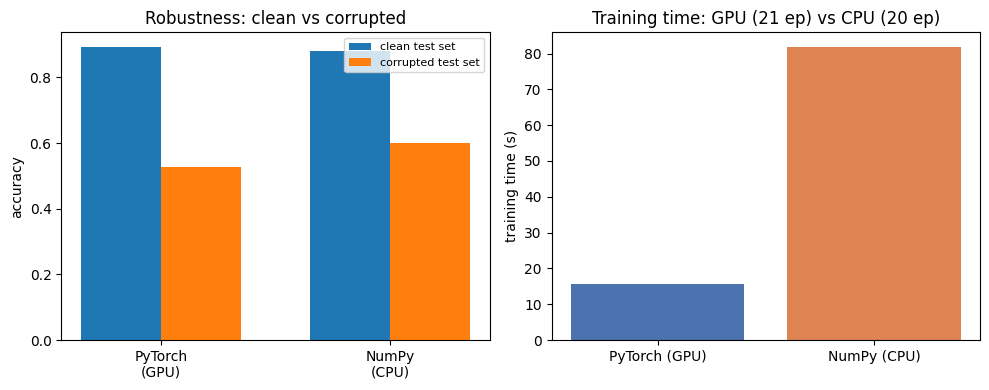

Saved part_e_gpu_robustness_and_time.png -- download this and report all printed numbers above back.


In [9]:
import torchvision.transforms.functional as TF
from PIL import Image

def corrupt_test_set(noise_std=0.3, max_rotation_deg=15, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    raw_test_images = raw_test.data.numpy().astype(np.float32) / 255.0  # (10000, 28, 28)
    corrupted = np.zeros_like(raw_test_images)
    for i in range(raw_test_images.shape[0]):
        angle = rng.uniform(-max_rotation_deg, max_rotation_deg)
        img = Image.fromarray((raw_test_images[i]*255).astype(np.uint8))
        img = TF.rotate(img, angle, fill=0)
        arr = np.array(img).astype(np.float32) / 255.0
        arr = arr + rng.normal(0, noise_std, arr.shape)
        corrupted[i] = np.clip(arr, 0, 1)
    flat = corrupted.reshape(corrupted.shape[0], -1)
    normed = (flat - mean) / std
    return normed

X_test_corrupt = corrupt_test_set()
X_test_corrupt_t = torch.tensor(X_test_corrupt, dtype=torch.float32, device=device)

net.eval()
with torch.no_grad():
    corrupt_preds_torch = net(X_test_corrupt_t).argmax(1).cpu().numpy()
torch_corrupt_acc = (corrupt_preds_torch == y_test_np).mean()

corrupt_preds_np = np_model.predict(X_test_corrupt.astype(np.float64))
np_corrupt_acc = (corrupt_preds_np == y_test_np).mean()

print(f"PyTorch: clean {torch_test_acc:.4f} -> corrupted {torch_corrupt_acc:.4f}  "
      f"(drop {torch_test_acc-torch_corrupt_acc:.4f})")
print(f"NumPy:   clean {np_test_acc:.4f} -> corrupted {np_corrupt_acc:.4f}  "
      f"(drop {np_test_acc-np_corrupt_acc:.4f})")
print("""
Discussion: both models share the identical regularization mechanism
(dropout p=0.3 + batchnorm), so a similar robustness drop between them
would suggest the corruption is attacking the shared architecture/data
distribution rather than a framework-specific quirk. A meaningfully larger
drop for one model would point to optimizer or hardware-precision
differences (e.g. GPU's fp32 vs NumPy's float64) mattering more under
distribution shift than they did on the clean test set.
""")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
idx_examples = np.random.RandomState(0).choice(10000, 5, replace=False)
for k, idx in enumerate(idx_examples):
    pass
labels = ["PyTorch\n(GPU)", "NumPy\n(CPU)"]
clean = [torch_test_acc, np_test_acc]
corrupt = [torch_corrupt_acc, np_corrupt_acc]
x = np.arange(2); w = 0.35
ax[0].bar(x-w/2, clean, w, label="clean test set")
ax[0].bar(x+w/2, corrupt, w, label="corrupted test set")
ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_ylabel("accuracy"); ax[0].set_title("Robustness: clean vs corrupted")
ax[0].legend(fontsize=8)

ax[1].bar(["PyTorch (GPU)", "NumPy (CPU)"], [gpu_train_time, np_train_time], color=["#4C72B0","#DD8452"])
ax[1].set_ylabel("training time (s)")
ax[1].set_title(f"Training time: GPU ({len(train_losses)} ep) vs CPU ({NP_EPOCHS} ep)")
fig.tight_layout()
fig.savefig("part_e_gpu_robustness_and_time.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved part_e_gpu_robustness_and_time.png -- download this and report all printed numbers above back.")

## Report back

Please copy back (or download the printed cell outputs / screenshot) the
following, so they can be folded into the Task 22 report with real numbers:

1. GPU device name and CUDA availability (Part D1-D2 output)
2. CPU-vs-GPU matmul benchmark: both times and the speedup factor (Part D3)
3. FP32 vs mixed-precision training step time, memory, and speedup (Part D4)
4. PyTorch (GPU) training curve summary: final train/val loss & accuracy,
   epochs run, early-stopping epoch if triggered, total GPU training time
   (Part E-GPU-1)
5. NumPy (CPU, this notebook) test accuracy and training time (Part E-GPU-2)
6. Prediction agreement rate + per-class accuracy table (Part E-GPU-3)
7. Robustness stress-test: clean vs corrupted accuracy for both models
   (Part E-GPU-4)
8. The saved figure `part_e_gpu_robustness_and_time.png`

All of these are printed directly by the cells above -- no extra work
needed beyond running the notebook (Runtime > Run all) and copying the
output.